<a href="https://colab.research.google.com/github/sjagadee/py_torch_from_basics/blob/main/projects/Rice_Classification_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Preparing the Environment
First, we install a tool called `opendatasets` which allows us to easily download data from the internet (specifically from Kaggle) directly into our workspace.

In [1]:
# Load data
!pip install opendatasets --quiet

In [2]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: srinijagadeesh
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mssmartypants/rice-type-classification


100%|██████████| 888k/888k [00:00<00:00, 129MB/s]

### 2. Importing Tools
Here we import our 'toolbox'. This includes tools for mathematical calculations (`numpy`), handling data tables (`pandas`), creating charts (`matplotlib`), and building the artificial intelligence model itself (`torch`).

In [3]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### 3. Loading and Cleaning Data
We load the rice classification information into a table. We then perform a 'clean-up' by removing any empty rows or unnecessary identification numbers so the model only focuses on the important features.

In [4]:
data_df = pd.read_csv("/content/rice-type-classification/riceClassification.csv")
data_df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [5]:
data_df.dropna(inplace=True)
data_df.drop(columns=["id"], inplace=True)
data_df.shape

(18185, 11)

In [6]:
data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [7]:
data_df["Class"].value_counts()

,count
Class,
1,9985
0,8200


### 4. Normalizing the Data
Different measurements have different scales (like comparing thousands to decimals). We rescale everything to be between 0 and 1. This ensures that no single measurement accidentally dominates the learning process just because its numbers are larger.

In [8]:
# Lets us make a copy of the data set for final inference
original_df = data_df.copy()

In [9]:
# Lets scale/normalize the data by dividing the valus by the max in that column
for column in data_df.columns:
    data_df[column] = data_df[column] / data_df[column].abs().max()

data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [10]:
# Lets not extract input features and output label

X = np.array(data_df.iloc[:, :-1])
y = np.array(data_df.iloc[:, -1])

### 5. Splitting the Data
We split our data into three groups:
* **Training set**: To teach the model.
* **Validation set**: To check its progress while it learns.
* **Test set**: To give it a final exam on data it hasn't seen before.

In [11]:
X[1]

array([0.28129285, 0.40768133, 0.62265269, 0.75048874, 0.27389172,
       0.53037048, 0.80423032, 0.40966075, 0.91921498, 0.37147093])

In [12]:
y[1]

np.float64(1.0)

In [13]:
# Split the data into three parts:
# Train:Test:Val = 70:15:15

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

In [14]:
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of X_val:", X_val.shape)

Shape of X_train: (12729, 10)
Shape of X_test: (2728, 10)
Shape of X_val: (2728, 10)


### 6. Creating Data Loaders
We wrap our data into special 'containers' that feed the information to the AI model in small, manageable bites (batches) rather than all at once.

In [15]:
# Let's create a custom dataset

class RiceDataset(Dataset):
    def __init__(self, features, label):
        self.features = torch.tensor(features, dtype=torch.float32).to(device)
        self.label = torch.tensor(label, dtype=torch.float32).to(device)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.label[idx]

In [17]:
rice_dataset_train = RiceDataset(X_train, y_train)
rice_dataset_val = RiceDataset(X_val, y_val)
rice_dataset_test = RiceDataset(X_test, y_test)

rice_dataloader_train = DataLoader(rice_dataset_train, batch_size=8, shuffle=True)
rice_dataloader_val = DataLoader(rice_dataset_val, batch_size=8, shuffle=True)
rice_dataloader_test = DataLoader(rice_dataset_test, batch_size=8, shuffle=True)

### 7. Designing the Model
We define the 'brain' of our AI. It’s a simple neural network that takes the rice measurements as input and tries to decide which class the rice belongs to.

In [18]:
for features, label in rice_dataloader_train:
    print("Features:", features)
    print("Label:", label)
    break

Features: tensor([[0.5459, 0.7895, 0.6045, 0.9709, 0.5195, 0.7389, 0.9160, 0.6438, 0.7224,
         0.7409],
        [0.5133, 0.8083, 0.5648, 0.9818, 0.4962, 0.7165, 0.5712, 0.6453, 0.6761,
         0.8119],
        [0.4847, 0.7532, 0.5663, 0.9732, 0.4644, 0.6962, 0.6230, 0.6061, 0.7237,
         0.7546],
        [0.6001, 0.8150, 0.6522, 0.9648, 0.5700, 0.7747, 0.5609, 0.6652, 0.7437,
         0.7089],
        [0.8827, 0.8547, 0.9066, 0.9086, 0.8410, 0.9395, 0.7909, 0.7514, 0.8574,
         0.5348],
        [0.8263, 0.8399, 0.8529, 0.9197, 0.7812, 0.9090, 0.8760, 0.7205, 0.8729,
         0.5587],
        [0.5631, 0.8099, 0.6041, 0.9742, 0.5330, 0.7504, 0.6910, 0.6462, 0.7395,
         0.7607],
        [0.4461, 0.6446, 0.6167, 0.9333, 0.4298, 0.6679, 0.7978, 0.5569, 0.7889,
         0.5930]], device='cuda:0')
Label: tensor([1., 1., 1., 1., 0., 0., 1., 1.], device='cuda:0')


In [19]:
# Build the model
HIDDEN_NEURONS = 10
class RiceClassificationModel(nn.Module):
    def __init__(self):
        super(RiceClassificationModel, self).__init__()
        self.input_layer = nn.Linear(X_train.shape[1], HIDDEN_NEURONS)
        self.linear = nn.Linear(HIDDEN_NEURONS, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_data):
        output = self.input_layer(input_data)
        output = self.linear(output)
        output = self.sigmoid(output)
        return output

In [22]:
model = RiceClassificationModel().to(device)
summary(model, (X_train.shape[1], ))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [23]:
# Loss Function
critirion = nn.BCELoss()

# Optimizer
optimizer = Adam(model.parameters(), lr=1e-3)

### 8. Training the Model
This is the learning phase. The model looks at the training data, makes a guess, checks if it was right, and adjusts itself to be more accurate. We repeat this process 10 times (epochs).

In [29]:
# training loop
total_loss_train = []
total_loss_val = []

total_acc_train = []
total_acc_val = []

EPOCHS = 10

for epoch in range(EPOCHS):
    loss_train = 0.0
    loss_val = 0.0

    acc_train = 0.0
    acc_val = 0.0

    model.train()
    for features, label in rice_dataloader_train:
        optimizer.zero_grad()
        output = model(features) # calling forward function
        batch_loss = critirion(output, label.unsqueeze(1))

        loss_train += batch_loss.item()

        accuracy = (output.round() == label.unsqueeze(1)).sum().item()
        acc_train += accuracy

        batch_loss.backward() # will calculate all the gradients
        optimizer.step() # update the weights and biases

    model.eval()
    with torch.no_grad():
        for features, label in rice_dataloader_val:
            output = model(features)
            batch_loss = critirion(output, label.unsqueeze(1))

            loss_val += batch_loss.item()

            accuracy = (output.round() == label.unsqueeze(1)).sum().item()
            acc_val += accuracy


    total_loss_train.append(round(loss_train/1000, 4))
    total_loss_val.append(round(loss_val/1000, 4))

    total_acc_train.append(round(acc_train/rice_dataset_train.__len__() * 100, 4))
    total_acc_val.append(round(acc_val/rice_dataset_val.__len__() * 100, 4))

    print(f'''Epoch {epoch+1}
          \nTrain Loss: {total_loss_train[-1]} | Train Acc: {total_acc_train[-1]}
          \nVal Loss: {total_loss_val[-1]} | Val Acc: {total_acc_val[-1]}''')

Epoch 1
          
Train Loss: 0.5867 | Train Acc: 92.8745
          
Val Loss: 0.0439 | Val Acc: 98.5337
Epoch 2
          
Train Loss: 0.1385 | Train Acc: 98.3895
          
Val Loss: 0.0213 | Val Acc: 98.607
Epoch 3
          
Train Loss: 0.0882 | Train Acc: 98.5073
          
Val Loss: 0.0181 | Val Acc: 98.3504
Epoch 4
          
Train Loss: 0.0758 | Train Acc: 98.5073
          
Val Loss: 0.0154 | Val Acc: 98.607
Epoch 5
          
Train Loss: 0.0714 | Train Acc: 98.5781
          
Val Loss: 0.0151 | Val Acc: 98.607
Epoch 6
          
Train Loss: 0.0699 | Train Acc: 98.5309
          
Val Loss: 0.0158 | Val Acc: 98.4604
Epoch 7
          
Train Loss: 0.0687 | Train Acc: 98.5781
          
Val Loss: 0.0155 | Val Acc: 98.4604
Epoch 8
          
Train Loss: 0.0693 | Train Acc: 98.5309
          
Val Loss: 0.0151 | Val Acc: 98.5704
Epoch 9
          
Train Loss: 0.0688 | Train Acc: 98.5231
          
Val Loss: 0.0155 | Val Acc: 98.4604
Epoch 10
          
Train Loss: 0.0683 | Train Ac

### 9. Final Test and Visualization
We run the model on the test data to see its final grade and create graphs to visualize how its accuracy improved over time.

In [30]:
loss_test = 0.0
acc_test = 0.0

model.eval()
with torch.no_grad():
    for features, label in rice_dataloader_test:
        output = model(features)
        batch_loss = critirion(output, label.unsqueeze(1))

        loss_test += batch_loss.item()

        accuracy = (output.round() == label.unsqueeze(1)).sum().item()
        acc_test += accuracy

print(f'''Test Loss: {round(loss_test/rice_dataset_test.__len__(), 4)} | Test Acc: {round(acc_test/rice_dataset_test.__len__() * 100, 4)}''')


Test Loss: 0.0036 | Test Acc: 98.9736


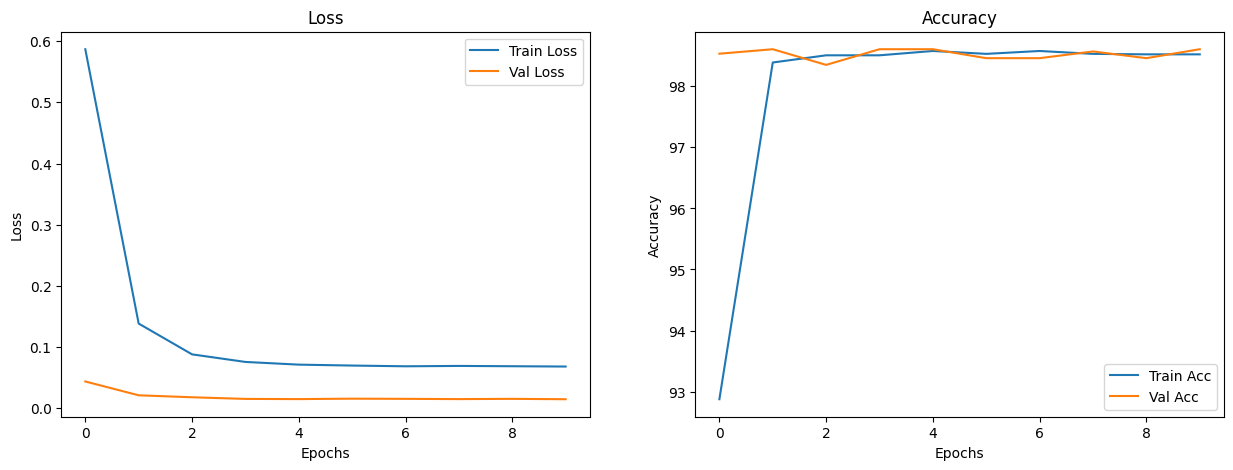

In [32]:
# visualizations

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

ax[0].plot(total_loss_train, label="Train Loss")
ax[0].plot(total_loss_val, label="Val Loss")
ax[0].set_title("Loss")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss")
ax[0].legend()

ax[1].plot(total_acc_train, label="Train Acc")
ax[1].plot(total_acc_val, label="Val Acc")
ax[1].set_title("Accuracy")
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Accuracy")
ax[1].legend()

plt.show()

### 10. Making Predictions (Inference)
In this final section, you can manually type in the measurements of a piece of rice, and the model will tell you which category it thinks it belongs to.

In [ ]:
# Inference
area = float(input("Area: "))/original_df['Area'].abs().max()
MajorAxisLength = float(input("Major Axis Length: "))/original_df['MajorAxisLength'].abs().max()
MinorAxisLength = float(input("Minor Axis Length: "))/original_df['MinorAxisLength'].abs().max()
Eccentricity = float(input("Eccentricity: "))/original_df['Eccentricity'].abs().max()
ConvexArea = float(input("Convex Area: "))/original_df['ConvexArea'].abs().max()
EquivDiameter = float(input("EquivDiameter: "))/original_df['EquivDiameter'].abs().max()
Extent = float(input("Extent: "))/original_df['Extent'].abs().max()
Perimeter = float(input("Perimeter: "))/original_df['Perimeter'].abs().max()
Roundness = float(input("Roundness: "))/original_df['Roundness'].abs().max()
AspectRation = float(input("AspectRation: "))/original_df['AspectRation'].abs().max()

my_inputs = [area, MajorAxisLength, MinorAxisLength, Eccentricity, ConvexArea, EquivDiameter, Extent, Perimeter, Roundness, AspectRation]

print("="*20)
model_inputs = torch.Tensor(my_inputs).to(device)
prediction = (model(model_inputs))
print(prediction)
print("Class is: ", round(prediction.item()))